# Binomial Tree Runtime Comparison

This notebook compares two implementations of binomial option pricing: a slower nested-loop version and a faster vectorized NumPy version. Both use the same pricing logic, but the vectorized version reduces Python-level looping and scales better for large values of `N`.

The model works backward from terminal payoffs using the risk-neutral valuation formula:

$$
C_{i,j} = e^{-r\Delta t}\left(pC_{i+1,j+1} + (1-p)C_{i+1,j}\right)
$$

In [33]:
import numpy as np
import matplotlib.pyplot as plt

## Timing Helper

The decorator below prints the runtime for each pricing function call. It is useful for quick experiments while still returning the computed option value.

In [34]:
from functools import wraps
from time import time

def timing(f):
    @wraps(f)
    def wrap(*args, **kw):
        ts = time()
        result = f(*args, **kw)
        te = time()
        print('func:%r args:[%r, %r] took:%2.4f sec' %\
            (f.__name__, args, kw, te-ts))
        return result
    return wrap

## Shared Model Inputs

These inputs are reused by both implementations so the runtime comparison is based on the same option contract and binomial tree assumptions.

The stock price at a node is:

$$
S_{i,j} = S_0 u^j d^{i-j}
$$

The risk-neutral probability is:

$$
p = \frac{e^{r\Delta t} - d}{u - d}
$$

In [35]:
#initialize parameters

S0 = 100            #initial stock price
K = 100             #strike price
T = 1               #time in years
r = 0.06            #annual risk-free rate
N = 3               #number of time steps
u = 1.1             #up-factor
d = 1/u             #down-factor
opttype = 'C'       #option type, C:call, P:put

## Loop-Based Implementation

The slow implementation explicitly builds terminal prices and then uses nested loops to work backward through the tree. This is easy to follow, but becomes expensive as the number of steps increases.

Terminal payoffs are calculated as:

$$
\max(S_T - K, 0) \quad \text{for calls}
$$

$$
\max(K - S_T, 0) \quad \text{for puts}
$$

In [36]:
@timing
def binomial_tree_slow(K,S0,T,r,N,u,d,opttype='C'):
    dt = T/N
    p = (np.exp(r*dt)-d)/(u-d)
    disc = np.exp(-r*dt)
    S = np.zeros(N+1)
    C = np.zeros(N+1)
    S[0] = S0*d**N
    C[0] = max(S[0]-K, 0)
    for i in range(1, N+1):
        S[i] = S[i-1]*u**2
        if opttype == 'C':
            C[i] = max(S[i]-K, 0)
        else:
            C[i] = max(K-S[i], 0)
    for i in range(N, -1, -1):
        for j in range(0, i):
            C[j] = disc*(p*C[j+1] + (1-p)*C[j])
    return C[0]

binomial_tree_slow(K,S0,T,r,N,u,d)

func:'binomial_tree_slow' args:[(100, 100, 1, 0.06, 3, 1.1, 0.9090909090909091), {}] took:0.0001 sec


np.float64(10.145735799928826)

## Vectorized Implementation

The fast implementation uses NumPy arrays to calculate terminal payoffs and backward induction more compactly. This removes much of the Python loop overhead while preserving the same mathematical pricing step:

$$
V_i = e^{-r\Delta t}\left(pV_{i+1}^{up} + (1-p)V_{i+1}^{down}\right)
$$

In [37]:
@timing
def binomial_tree_fast(K,S0,T,r,N,u,d,opttype = 'C'):
    dt = T/N
    p = (np.exp(r*dt)-d)/(u-d)
    disc = np.exp(-r*dt)
    C = S0*d**(np.arange(N, -1, -1))*u**(np.arange(0, N+1, 1))
    if opttype == 'C':
        C = np.maximum(C-K, np.zeros(N+1))
    else:
        C = np.maximum(K-C, np.zeros(N+1))
    for i in range(N, 0, -1):
        C = disc*(p*C[1:i+1] + (1-p)*C[0:i])
    return C[0]
binomial_tree_fast(K,S0,T,r,N,u,d,'C')

func:'binomial_tree_fast' args:[(100, 100, 1, 0.06, 3, 1.1, 0.9090909090909091, 'C'), {}] took:0.0001 sec


np.float64(10.145735799928826)

## Runtime Plot

The next cell runs both functions across several tree sizes and plots their execution times on a linear scale.

func:'binomial_tree_slow' args:[(100, 100, 1, 0.06, 3, 1.1, 0.9090909090909091), {}] took:0.0000 sec
func:'binomial_tree_fast' args:[(100, 100, 1, 0.06, 3, 1.1, 0.9090909090909091), {}] took:0.0001 sec
func:'binomial_tree_slow' args:[(100, 100, 1, 0.06, 50, 1.1, 0.9090909090909091), {}] took:0.0007 sec
func:'binomial_tree_fast' args:[(100, 100, 1, 0.06, 50, 1.1, 0.9090909090909091), {}] took:0.0002 sec
func:'binomial_tree_slow' args:[(100, 100, 1, 0.06, 100, 1.1, 0.9090909090909091), {}] took:0.0025 sec
func:'binomial_tree_fast' args:[(100, 100, 1, 0.06, 100, 1.1, 0.9090909090909091), {}] took:0.0004 sec
func:'binomial_tree_slow' args:[(100, 100, 1, 0.06, 1000, 1.1, 0.9090909090909091), {}] took:0.3022 sec
func:'binomial_tree_fast' args:[(100, 100, 1, 0.06, 1000, 1.1, 0.9090909090909091), {}] took:0.0059 sec
func:'binomial_tree_slow' args:[(100, 100, 1, 0.06, 2000, 1.1, 0.9090909090909091), {}] took:0.8950 sec
func:'binomial_tree_fast' args:[(100, 100, 1, 0.06, 2000, 1.1, 0.90909090909

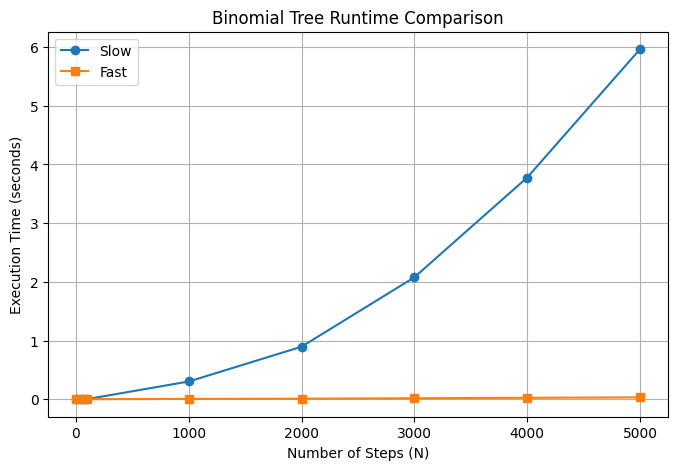

In [38]:
N_values = [3, 50, 100, 1000, 2000, 3000, 4000, 5000]

slow_times = []
fast_times = []

for N in N_values:

    start = time()
    binomial_tree_slow(K, S0, T, r, N, u, d)
    slow_times.append(time() - start)

    start = time()
    binomial_tree_fast(K, S0, T, r, N, u, d)
    fast_times.append(time() - start)

plt.figure(figsize=(8,5))
plt.plot(N_values, slow_times, marker='o', label='Slow')
plt.plot(N_values, fast_times, marker='s', label='Fast')

plt.xlabel("Number of Steps (N)")
plt.ylabel("Execution Time (seconds)")
plt.title("Binomial Tree Runtime Comparison")
plt.legend()
plt.grid(True)

plt.show()

## Log-Scale Runtime Plot

The final plot uses a logarithmic y-axis, which makes the speed difference easier to compare when runtimes vary by large factors.

func:'binomial_tree_slow' args:[(100, 100, 1, 0.06, 3, 1.1, 0.9090909090909091), {}] took:0.0000 sec
func:'binomial_tree_fast' args:[(100, 100, 1, 0.06, 3, 1.1, 0.9090909090909091), {}] took:0.0001 sec
func:'binomial_tree_slow' args:[(100, 100, 1, 0.06, 50, 1.1, 0.9090909090909091), {}] took:0.0012 sec
func:'binomial_tree_fast' args:[(100, 100, 1, 0.06, 50, 1.1, 0.9090909090909091), {}] took:0.0003 sec
func:'binomial_tree_slow' args:[(100, 100, 1, 0.06, 100, 1.1, 0.9090909090909091), {}] took:0.0036 sec
func:'binomial_tree_fast' args:[(100, 100, 1, 0.06, 100, 1.1, 0.9090909090909091), {}] took:0.0006 sec
func:'binomial_tree_slow' args:[(100, 100, 1, 0.06, 1000, 1.1, 0.9090909090909091), {}] took:0.2520 sec
func:'binomial_tree_fast' args:[(100, 100, 1, 0.06, 1000, 1.1, 0.9090909090909091), {}] took:0.0043 sec
func:'binomial_tree_slow' args:[(100, 100, 1, 0.06, 2000, 1.1, 0.9090909090909091), {}] took:0.9424 sec
func:'binomial_tree_fast' args:[(100, 100, 1, 0.06, 2000, 1.1, 0.90909090909

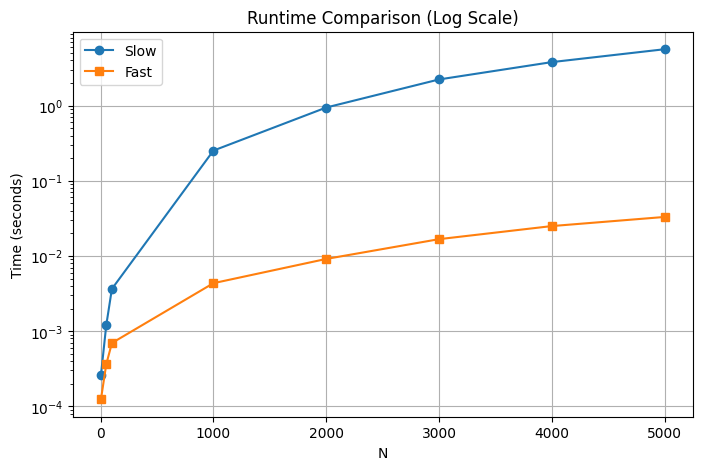

In [39]:
N_values = [3, 50, 100, 1000, 2000, 3000, 4000, 5000]

slow_times = []
fast_times = []

for N in N_values:

    start = time()
    binomial_tree_slow(K, S0, T, r, N, u, d)
    slow_times.append(time() - start)

    start = time()
    binomial_tree_fast(K, S0, T, r, N, u, d)
    fast_times.append(time() - start)

plt.figure(figsize=(8,5))
plt.plot(N_values, slow_times, marker='o', label='Slow')
plt.plot(N_values, fast_times, marker='s', label='Fast')

plt.yscale('log')

plt.xlabel('N')
plt.ylabel('Time (seconds)')
plt.title('Runtime Comparison (Log Scale)')
plt.legend()
plt.grid(True)

plt.show()